# Combined Human-Synthetic Dataset Comparision SMS Spam Detection using CNN in Keras

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
df = pd.read_csv("Merged_Human_And_Synthetic_SMSSpamCollection.csv", sep="\t")
print(df.head())

# Encode labels: ham = 0, spam = 1
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label_encoded"], test_size=0.2, random_state=42
)

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

maxlen = 100  # Max sequence length
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen)

vocab_size = len(tokenizer.word_index) + 1


  label                                            message
0   ham             Boy you best get yo ass out here quick
1  spam  and we'll check your credit score and send you...
2   ham           This is all just creepy and crazy to me.
3   ham  Si.como no?!listened2the plaid album-quite gd&...
4   ham  here in the suburbs of Edmonton, B.C., to get ...


In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

embedding_dim = 50  # Size of word vectors

# Input layer with fixed sequence length
inputs = Input(shape=(maxlen,))

# Embedding layer to convert word indices to dense vectors
embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen)(inputs)

# Convolutional layer: apply 128 filters of size 5
conv = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)

# Max pooling: pick the most important features (max value) from each filter
pool = GlobalMaxPooling1D()(conv)

# Dropout layer: randomly zero out 50% of neurons to prevent overfitting
drop = Dropout(0.5)(pool)

# Output layer: sigmoid for binary classification
output = Dense(1, activation='sigmoid')(drop)

# Create and compile the model
model = Model(inputs, output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Show model summary
model.summary()


/Users/srisairesu/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 50)        │       501,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 128)        │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 534,207 (2.04 MB)

 Trainable params: 534,207 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the model for 5 epochs with 10% validation split
history = model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.1)


Epoch 1/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7971 - loss: 0.4706 - val_accuracy: 0.9607 - val_loss: 0.1283
Epoch 2/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9577 - loss: 0.1261 - val_accuracy: 0.9681 - val_loss: 0.0998
Epoch 3/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9750 - loss: 0.0711 - val_accuracy: 0.9668 - val_loss: 0.0954
Epoch 4/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9828 - loss: 0.0481 - val_accuracy: 0.9668 - val_loss: 0.0984
Epoch 5/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9901 - loss: 0.0292 - val_accuracy: 0.9681 - val_loss: 0.1073


In [9]:
# Evaluate on the test set
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {accuracy:.2f}")


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9597 - loss: 0.1277
Test Accuracy: 0.96


In [10]:
# Function to make predictions on new messages
def predict_message(msg):
    seq = tokenizer.texts_to_sequences([msg])         # Convert text to sequence
    pad = pad_sequences(seq, maxlen=maxlen)           # Pad the sequence
    pred = model.predict(pad)[0][0]                   # Get prediction probability
    return "Spam" if pred > 0.5 else "Ham"            # Threshold at 0.5

# Predictions on new messages
print(predict_message("Congratulations! You have won a free ticket. Call now."))  # Expected: Spam
print(predict_message("Hi, are we still on for lunch?"))                         # Expected: Ham


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Ham


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Generate predictions on test set
# -----------------------------
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()   # Convert probabilities to 0/1

# -----------------------------
# Compute metrics
# -----------------------------
cnn_accuracy = accuracy_score(y_test, y_pred)
cnn_precision = precision_score(y_test, y_pred)
cnn_recall = recall_score(y_test, y_pred)
cnn_f1 = f1_score(y_test, y_pred)

print("===== Model Performance =====")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
===== Model Performance =====
Accuracy:  0.9592
Precision: 0.9522
Recall:    0.8633
F1 Score:  0.9056


Confusion Matrix:
[[1552   20]
 [  63  398]]


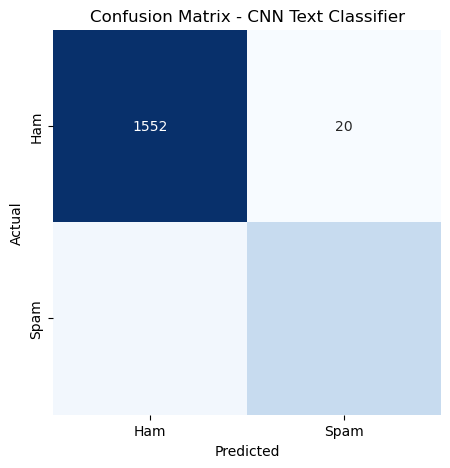

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix dynamically
cnn_cm = confusion_matrix(y_test_int, y_pred_int, labels=[0, 1])  # 0=Ham, 1=Spam

# Print confusion matrix in text
print("Confusion Matrix:")
print(cnn_cm)

# Class labels
labels = ["Ham", "Spam"]

# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar=False)  # optional: remove color bar for clarity
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN Text Classifier")
plt.show()


# Combined Human-Synthetic Comparision Spam Detection Using Logistic Regression / SVM

In [34]:
import pandas as pd
import numpy as np
import re

# Load the same dataset used for CNN
data = pd.read_csv("Merged_Human_And_Synthetic_SMSSpamCollection.csv", sep="\t")

# --- Cleaning function ---
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove digits
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    return text

# Apply cleaning
data['cleaned_message'] = data['message'].apply(clean_text)
data.head()


,label,message,cleaned_message
0,ham,Boy you best get yo ass out here quick,boy you best get yo ass out here quick
1,spam,and we'll check your credit score and send you...,and well check your credit score and send you ...
2,ham,This is all just creepy and crazy to me.,this is all just creepy and crazy to me
3,ham,Si.como no?!listened2the plaid album-quite gd&...,sicomo nolistenedthe plaid albumquite gdthe ne...
4,ham,"here in the suburbs of Edmonton, B.C., to get ...",here in the suburbs of edmonton bc to get on t...


In [35]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['label_encoded'] = label_encoder.fit_transform(data['label'])   # ham=0, spam=1


In [36]:
from sklearn.model_selection import train_test_split

X = data['cleaned_message']
y = data['label_encoded']

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X, y, test_size=0.2, random_state=42
)

len(X_train_clean), len(X_test_clean)


(8132, 2033)

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

X_train_tfidf.shape, X_test_tfidf.shape


((8132, 5000), (2033, 5000))

In [38]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train_tfidf, y_train_clean)

log_reg_preds = log_reg_model.predict(X_test_tfidf)


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# Compute metrics for Logistic Regression
# -----------------------------
logreg_accuracy = accuracy_score(y_test_clean, log_reg_preds)
logreg_precision = precision_score(y_test_clean, log_reg_preds)
logreg_recall = recall_score(y_test_clean, log_reg_preds)
logreg_f1 = f1_score(y_test_clean, log_reg_preds)

print("===== Logistic Regression Performance =====")
print(f"Accuracy:  {logreg_accuracy:.4f}")
print(f"Precision: {logreg_precision:.4f}")
print(f"Recall:    {logreg_recall:.4f}")
print(f"F1 Score:  {logreg_f1:.4f}")


===== Logistic Regression Performance =====
Accuracy:  0.9351
Precision: 0.9608
Recall:    0.7440
F1 Score:  0.8386


In [40]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train_clean)

svm_preds = svm_model.predict(X_test_tfidf)


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# Compute metrics for SVM
# -----------------------------
svm_accuracy = accuracy_score(y_test_clean, svm_preds)
svm_precision = precision_score(y_test_clean, svm_preds)
svm_recall = recall_score(y_test_clean, svm_preds)
svm_f1 = f1_score(y_test_clean, svm_preds)

print("===== SVM Performance =====")
print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1 Score:  {svm_f1:.4f}")



===== SVM Performance =====
Accuracy:  0.9518
Precision: 0.9459
Recall:    0.8351
F1 Score:  0.8871


Confusion Matrix:
[[1558   14]
 [ 118  343]]


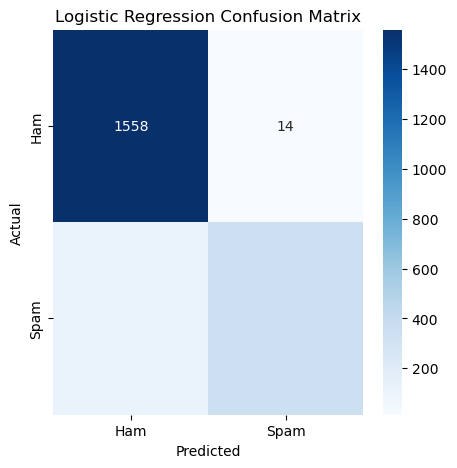

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

log_cm = confusion_matrix(y_test_clean, log_reg_preds)

# Print confusion matrix in text
print("Confusion Matrix:")
print(log_cm)

plt.figure(figsize=(5,5))
sns.heatmap(log_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Confusion Matrix:
[[1550   22]
 [  76  385]]


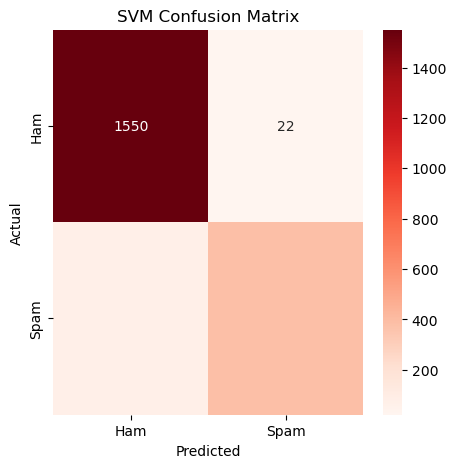

In [48]:
svm_cm = confusion_matrix(y_test_clean, svm_preds)

# Print confusion matrix in text
print("Confusion Matrix:")
print(svm_cm)

plt.figure(figsize=(5,5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [50]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Load Human + Synthetic merged dataset
data_blstm = pd.read_csv("Merged_Human_And_Synthetic_SMSSpamCollection.csv", sep="\t")

# Preview
data_blstm.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/srisairesu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message
0,ham,Boy you best get yo ass out here quick
1,spam,and we'll check your credit score and send you...
2,ham,This is all just creepy and crazy to me.
3,ham,Si.como no?!listened2the plaid album-quite gd&...
4,ham,"here in the suburbs of Edmonton, B.C., to get ..."


In [51]:
def preprocess_text_blstm(text):
    text = re.sub(r'\W', ' ', text)     # remove non-word characters
    text = re.sub(r'\s+', ' ', text)    # remove multiple spaces
    return text.lower()                 # convert to lowercase

data_blstm["clean_message"] = data_blstm["message"].apply(preprocess_text_blstm)
data_blstm.head()


,label,message,clean_message
0,ham,Boy you best get yo ass out here quick,boy you best get yo ass out here quick
1,spam,and we'll check your credit score and send you...,and we ll check your credit score and send you...
2,ham,This is all just creepy and crazy to me.,this is all just creepy and crazy to me
3,ham,Si.como no?!listened2the plaid album-quite gd&...,si como no listened2the plaid album quite gd t...
4,ham,"here in the suburbs of Edmonton, B.C., to get ...",here in the suburbs of edmonton b c to get on ...


In [52]:
data_blstm["label_encoded"] = data_blstm["label"].map({"ham": 0, "spam": 1})

X_blstm = data_blstm["clean_message"]
y_blstm = data_blstm["label_encoded"]


In [53]:
from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_blstm, y_blstm, test_size=0.2, random_state=42
)


In [55]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer_blstm = Tokenizer(num_words=5000)
tokenizer_blstm.fit_on_texts(X_train_b)

X_train_seq_b = tokenizer_blstm.texts_to_sequences(X_train_b)
X_test_seq_b = tokenizer_blstm.texts_to_sequences(X_test_b)

max_len_blstm = 100

X_train_pad_b = pad_sequences(X_train_seq_b, maxlen=max_len_blstm)
X_test_pad_b = pad_sequences(X_test_seq_b, maxlen=max_len_blstm)


In [56]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Bidirectional
from keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense

model_blstm = Sequential()

model_blstm.add(Embedding(input_dim=5000, output_dim=128, input_length=max_len_blstm))

# BLSTM layer
model_blstm.add(Bidirectional(LSTM(64, return_sequences=True)))

# CNN layer
model_blstm.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model_blstm.add(MaxPooling1D(pool_size=2))
model_blstm.add(GlobalMaxPooling1D())

# Output layer
model_blstm.add(Dense(1, activation='sigmoid'))

# Compile model
model_blstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_blstm.summary()


/Users/srisairesu/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
history_blstm = model_blstm.fit(
    X_train_pad_b, 
    y_train_b, 
    epochs=5, 
    batch_size=64, 
    validation_data=(X_test_pad_b, y_test_b)
)


Epoch 1/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.8009 - loss: 0.4283 - val_accuracy: 0.9543 - val_loss: 0.1429
Epoch 2/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.9660 - loss: 0.0986 - val_accuracy: 0.9656 - val_loss: 0.1133
Epoch 3/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.9840 - loss: 0.0500 - val_accuracy: 0.9611 - val_loss: 0.1324
Epoch 4/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - accuracy: 0.9895 - loss: 0.0304 - val_accuracy: 0.9631 - val_loss: 0.1522
Epoch 5/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - accuracy: 0.9921 - loss: 0.0209 - val_accuracy: 0.9606 - val_loss: 0.1843


In [58]:
y_pred_prob_b = model_blstm.predict(X_test_pad_b)
y_pred_b = (y_pred_prob_b > 0.5).astype(int)


64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

blstm_accuracy = accuracy_score(y_test_b, y_pred_b)
blstm_precision = precision_score(y_test_b, y_pred_b)
blstm_recall = recall_score(y_test_b, y_pred_b)
blstm_f1 = f1_score(y_test_b, y_pred_b)

print("===== BLSTM + CNN Performance =====")
print(f"Accuracy:  {blstm_accuracy:.4f}")
print(f"Precision: {blstm_precision:.4f}")
print(f"Recall:    {blstm_recall:.4f}")
print(f"F1 Score:  {blstm_f1:.4f}")


===== BLSTM + CNN Performance =====
Accuracy:  0.9606
Precision: 0.9224
Recall:    0.9024
F1 Score:  0.9123


Confusion Matrix:
[[1537   35]
 [  45  416]]


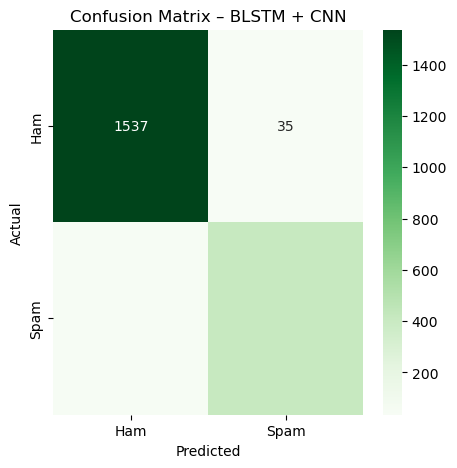

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_blstm = confusion_matrix(y_test_b, y_pred_b)

# Print confusion matrix in text
print("Confusion Matrix:")
print(cm_blstm)

plt.figure(figsize=(5,5))
sns.heatmap(cm_blstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – BLSTM + CNN")
plt.show()


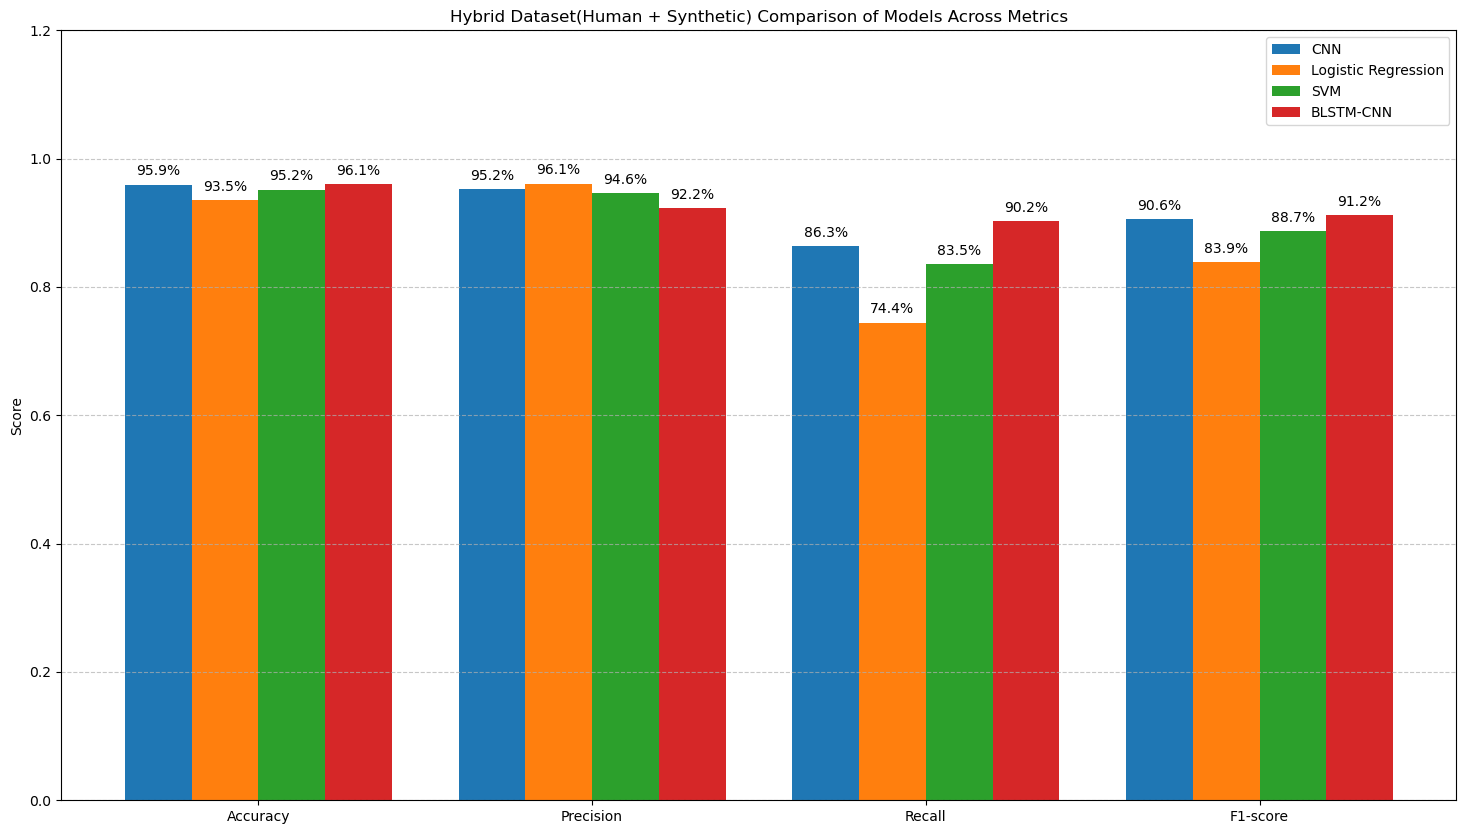

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Metrics for each model
# -----------------------------
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

cnn_metrics = [cnn_accuracy, cnn_precision, cnn_recall, cnn_f1]
logreg_metrics = [logreg_accuracy, logreg_precision, logreg_recall, logreg_f1]
svm_metrics = [svm_accuracy, svm_precision, svm_recall, svm_f1]
blstm_metrics = [blstm_accuracy, blstm_precision, blstm_recall, blstm_f1]

# -----------------------------
# Set up bar positions
# -----------------------------
x = np.arange(len(metrics))  # metric positions
width = 0.2  # width of each bar

# -----------------------------
# Plot grouped bar chart
# -----------------------------
plt.figure(figsize=(18,10))

bars1 = plt.bar(x - 1.5*width, cnn_metrics, width, label='CNN')
bars2 = plt.bar(x - 0.5*width, logreg_metrics, width, label='Logistic Regression')
bars3 = plt.bar(x + 0.5*width, svm_metrics, width, label='SVM')
bars4 = plt.bar(x + 1.5*width, blstm_metrics, width, label='BLSTM-CNN')

# -----------------------------
# Add values on top of each bar
# -----------------------------
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height*100:.1f}%', 
                 ha='center', va='bottom', fontsize=10)

# -----------------------------
plt.xticks(x, metrics)
plt.ylim(0, 1.2)  # extend y-limit for text
plt.ylabel("Score")
plt.title("Hybrid Dataset(Human + Synthetic) Comparison of Models Across Metrics")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Compute Confidence Intervals Using Bootstrap Sampling

In [70]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def bootstrap_ci(y_true, y_pred, metric_func, n_bootstraps=1000, alpha=0.95):
    """
    Compute confidence interval using bootstrap sampling.
    """
    stats = []
    n = len(y_true)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    for _ in range(n_bootstraps):
        indices = np.random.randint(0, n, n)
        stats.append(metric_func(y_true[indices], y_pred[indices]))
    lower = np.percentile(stats, (1-alpha)/2*100)
    upper = np.percentile(stats, (alpha + (1-alpha)/2)*100)
    return lower, upper


In [71]:
models = {
    "CNN": (y_test, y_pred),
    "BLSTM+CNN": (y_test_b, y_pred_b),
    "Logistic Regression": (y_test_clean, log_reg_preds),
    "SVM": (y_test_clean, svm_preds)
}

metrics = [("Accuracy", accuracy_score),
           ("Precision", precision_score),
           ("Recall", recall_score),
           ("F1 Score", f1_score)]

for model_name, (y_true, y_hat) in models.items():
    print(f"\n===== {model_name} Performance =====")
    for metric_name, metric_func in metrics:
        score = metric_func(y_true, y_hat)
        ci_lower, ci_upper = bootstrap_ci(y_true, y_hat, metric_func)
        print(f"{metric_name}: {score:.4f} (95% CI: {ci_lower:.4f} - {ci_upper:.4f})")



===== CNN Performance =====
Accuracy: 0.9592 (95% CI: 0.9513 - 0.9675)
Precision: 0.9522 (95% CI: 0.9311 - 0.9714)
Recall: 0.8633 (95% CI: 0.8296 - 0.8921)
F1 Score: 0.9056 (95% CI: 0.8843 - 0.9241)

===== BLSTM+CNN Performance =====
Accuracy: 0.9606 (95% CI: 0.9508 - 0.9685)
Precision: 0.9224 (95% CI: 0.8986 - 0.9468)
Recall: 0.9024 (95% CI: 0.8722 - 0.9289)
F1 Score: 0.9123 (95% CI: 0.8914 - 0.9310)

===== Logistic Regression Performance =====
Accuracy: 0.9351 (95% CI: 0.9252 - 0.9464)
Precision: 0.9608 (95% CI: 0.9391 - 0.9792)
Recall: 0.7440 (95% CI: 0.7054 - 0.7835)
F1 Score: 0.8386 (95% CI: 0.8089 - 0.8645)

===== SVM Performance =====
Accuracy: 0.9518 (95% CI: 0.9429 - 0.9606)
Precision: 0.9459 (95% CI: 0.9244 - 0.9675)
Recall: 0.8351 (95% CI: 0.8016 - 0.8693)
F1 Score: 0.8871 (95% CI: 0.8654 - 0.9089)


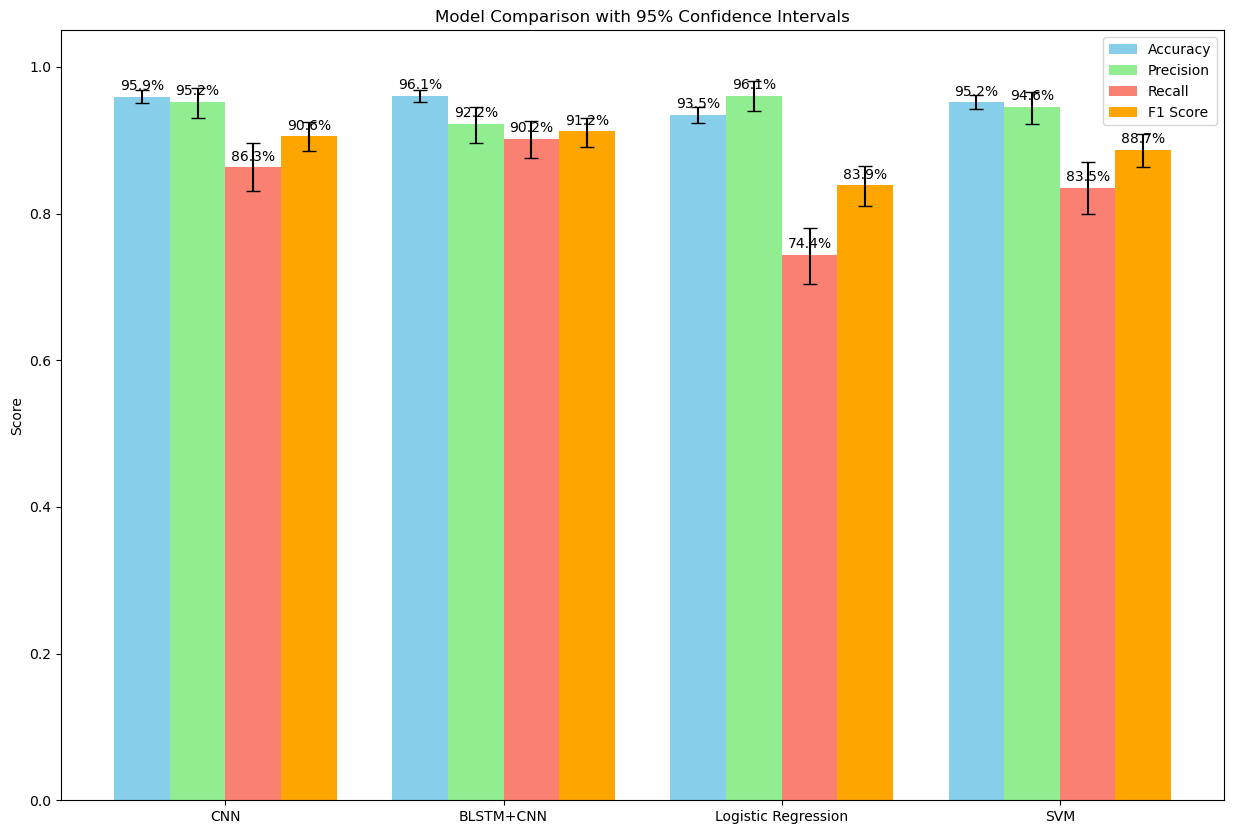

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Bootstrap function (reuse from before)
def bootstrap_ci(y_true, y_pred, metric_func, n_bootstraps=1000, alpha=0.95):
    stats = []
    n = len(y_true)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    for _ in range(n_bootstraps):
        indices = np.random.randint(0, n, n)
        stats.append(metric_func(y_true[indices], y_pred[indices]))
    lower = np.percentile(stats, (1-alpha)/2*100)
    upper = np.percentile(stats, (alpha + (1-alpha)/2)*100)
    return lower, upper

# Models and their predictions
models = {
    "CNN": (y_test, y_pred),
    "BLSTM+CNN": (y_test_b, y_pred_b),
    "Logistic Regression": (y_test_clean, log_reg_preds),
    "SVM": (y_test_clean, svm_preds)
}

metrics = [("Accuracy", accuracy_score),
           ("Precision", precision_score),
           ("Recall", recall_score),
           ("F1 Score", f1_score)]

# Prepare data for plotting
model_names = list(models.keys())
metric_names = [m[0] for m in metrics]
metric_values = {metric: [] for metric in metric_names}
metric_errors = {metric: [] for metric in metric_names}

for model_name, (y_true, y_hat) in models.items():
    for metric_name, metric_func in metrics:
        score = metric_func(y_true, y_hat)
        ci_lower, ci_upper = bootstrap_ci(y_true, y_hat, metric_func)
        metric_values[metric_name].append(score)
        # Error bar = distance from mean to upper/lower CI
        metric_errors[metric_name].append([[score - ci_lower], [ci_upper - score]])

# Plot grouped bar chart with error bars
x = np.arange(len(model_names))  # model positions
width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(15, 10))

colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

for i, metric_name in enumerate(metric_names):
    values = metric_values[metric_name]
    errors = np.array(metric_errors[metric_name]).squeeze().T  # shape (2, n_models)
    ax.bar(x + i*width, values, width, label=metric_name, color=colors[i],
           yerr=errors, capsize=5)

# Add values on top of bars in percentage
for i, metric_name in enumerate(metric_names):
    for j, value in enumerate(metric_values[metric_name]):
        ax.text(x[j] + i*width, value + 0.005, f"{value*100:.1f}%", ha='center', va='bottom', fontsize=10)

ax.set_xticks(x + 1.5*width)  # center group of bars
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison with 95% Confidence Intervals")
ax.legend()
plt.show()


## McNemar’s test:

McNemar’s test compares two classifiers on the same test set to see if their prediction differences are statistically significant.

Null hypothesis (H₀): Both models have the same error rate (i.e., no significant difference in performance).

Alternative hypothesis (H₁): The models have different error rates.

p-value < 0.05 → reject H₀ → significant difference.

p-value ≥ 0.05 → fail to reject H₀ → no significant difference.

In [78]:
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations
import numpy as np

# -----------------------------
# Ensure all predictions are 1D arrays
# -----------------------------
y_pred_cnn = y_pred.flatten() if y_pred.ndim > 1 else y_pred
y_pred_blstm = y_pred_b.flatten() if y_pred_b.ndim > 1 else y_pred_b
logreg_preds_flat = log_reg_preds.flatten() if log_reg_preds.ndim > 1 else log_reg_preds
svm_preds_flat = svm_preds.flatten() if svm_preds.ndim > 1 else svm_preds

# -----------------------------
# Function to perform McNemar's test
# -----------------------------
def mcnemar_test(y_true, pred1, pred2, alpha=0.05):
    """
    Performs McNemar's test between two classifiers.
    Returns p-value and significance interpretation.
    """
    # Build contingency table
    # [[pred1 correct & pred2 correct, pred1 correct & pred2 wrong],
    #  [pred1 wrong & pred2 correct, pred1 wrong & pred2 wrong]]
    both_correct = np.sum((pred1 == y_true) & (pred2 == y_true))
    pred1_correct_pred2_wrong = np.sum((pred1 == y_true) & (pred2 != y_true))
    pred1_wrong_pred2_correct = np.sum((pred1 != y_true) & (pred2 == y_true))
    both_wrong = np.sum((pred1 != y_true) & (pred2 != y_true))

    table = [[both_correct, pred1_correct_pred2_wrong],
             [pred1_wrong_pred2_correct, both_wrong]]

    result = mcnemar(table, exact=True)
    p_val = result.pvalue

    interpretation = "Significant difference" if p_val < alpha else "No significant difference"
    return p_val, interpretation

# -----------------------------
# Prepare model predictions dictionary
# -----------------------------
models = {
    "CNN": y_pred_cnn,
    "BLSTM+CNN": y_pred_blstm,
    "Logistic Regression": logreg_preds_flat,
    "SVM": svm_preds_flat
}

# -----------------------------
# Pairwise McNemar's tests
# -----------------------------
print("===== McNemar's Test Results =====")
for model1, model2 in combinations(models.keys(), 2):
    p_val, interpretation = mcnemar_test(y_test, models[model1], models[model2])
    print(f"{model1} vs {model2} --> p-value: {p_val:.4f}, {interpretation}")


===== McNemar's Test Results =====
CNN vs BLSTM+CNN --> p-value: 0.8151, No significant difference
CNN vs Logistic Regression --> p-value: 0.0000, Significant difference
CNN vs SVM --> p-value: 0.1505, No significant difference
BLSTM+CNN vs Logistic Regression --> p-value: 0.0000, Significant difference
BLSTM+CNN vs SVM --> p-value: 0.0822, No significant difference
Logistic Regression vs SVM --> p-value: 0.0000, Significant difference
